## 1 · Installation & Imports

In [ ]:
# Install required packages (run once)
%pip install -q tensorflow tensorflow-text einops transformers

import os, re, pickle, pathlib, string
from collections import Counter
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import tensorflow as tf
import tensorflow_text as tf_text
import einops

from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Bidirectional, GRU as GRULayer,
    Conv1D, GlobalMaxPooling1D, TimeDistributed,
    Dropout, RepeatVector
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split

print("TensorFlow:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2 · Data Loading & Exploration

Two datasets are merged:
- `ara_eng.txt` — sentence pairs, tab-separated
- `ara.txt`     — sentence pairs with a CC attribution column (dropped)


In [ ]:
# ── Load datasets ─────────────────────────────────────────────────────────────
data1 = pd.read_csv(
    "/content/Arabic to English Translation Sentences/ara_eng.txt",
    delimiter="\t", names=["english", "arabic"]
)

data2 = pd.read_csv(
    "/content/  Arabic to English Sentences Dataset/ara.txt",
    delimiter="\t", names=["english", "arabic", "CC"]
).drop(columns=["CC"])

# Merge and deduplicate
data = pd.concat([data1, data2], ignore_index=True).drop_duplicates()
data = data.dropna(subset=["english", "arabic"]).reset_index(drop=True)

print(f"Total samples after dedup: {len(data):,}")
data.head()


Total samples after dedup: 26,487


,english,arabic
0,Hi.,مرحبًا.
1,Run!,اركض!
2,Help!,النجدة!
3,Jump!,اقفز!
4,Stop!,قف!


In [ ]:
# ── Sentence-length distribution ──────────────────────────────────────────────
import plotly.subplots as sp
import plotly.graph_objects as go

en_lens = data["english"].str.split().str.len()
ar_lens = data["arabic"].str.split().str.len()

fig = sp.make_subplots(rows=1, cols=2,
                       subplot_titles=("English Sentence Lengths",
                                       "Arabic Sentence Lengths"))
fig.add_trace(go.Histogram(x=en_lens, nbinsx=50, name="English"), row=1, col=1)
fig.add_trace(go.Histogram(x=ar_lens, nbinsx=50, name="Arabic"),  row=1, col=2)
fig.update_layout(title_text="Distribution of Sentence Lengths", showlegend=False)
fig.update_xaxes(title_text="Words per sentence")
fig.show()

print(f"English — mean: {en_lens.mean():.1f}, max: {en_lens.max()}")
print(f"Arabic  — mean: {ar_lens.mean():.1f}, max: {ar_lens.max()}")


English — mean: 16.8, max: 225
Arabic  — mean: 14.3, max: 225


In [ ]:
# ── Unique vocabulary size ─────────────────────────────────────────────────────
en_vocab = {w for s in data["english"] for w in str(s).lower().split()}
ar_vocab = {w for s in data["arabic"] for w in str(s).split()}

import plotly.graph_objects as go
fig = go.Figure([
    go.Bar(x=["English"], y=[len(en_vocab)], name="English"),
    go.Bar(x=["Arabic"],  y=[len(ar_vocab)], name="Arabic"),
])
fig.update_layout(title="Unique Vocabulary Size", barmode="group",
                  xaxis_title="Language", yaxis_title="Unique Words")
fig.show()


## 3 · Model A — Simple Seq2Seq (Word-level Tokenizer)

A baseline encoder–decoder using Keras word-level tokenization.  
Architecture: `Embedding → BiLSTM → RepeatVector → BiLSTM → TimeDistributed Dense`


In [ ]:
# ── Hyper-parameters ──────────────────────────────────────────────────────────
MAX_SEQ_LEN  = 10
EMBED_DIM    = 256
HIDDEN_UNITS = 256
BATCH_SIZE   = 64
OOV_TOKEN    = "<OOV>"

# ── Train / test split ────────────────────────────────────────────────────────
train_df, test_df = train_test_split(data, test_size=0.2, random_state=42)

# ── Fit word-level tokenizers on training data only ───────────────────────────
en_tokenizer = Tokenizer(oov_token=OOV_TOKEN, lower=True)
en_tokenizer.fit_on_texts(train_df["english"])
en_vocab_size = len(en_tokenizer.word_index) + 1

ar_tokenizer = Tokenizer(oov_token=OOV_TOKEN, lower=True)
ar_tokenizer.fit_on_texts(train_df["arabic"])
ar_vocab_size = len(ar_tokenizer.word_index) + 1

print(f"English vocab size: {en_vocab_size:,}")
print(f"Arabic  vocab size: {ar_vocab_size:,}")


English vocab size: 23,564
Arabic  vocab size: 52,044


In [ ]:
# ── Save tokenizers ───────────────────────────────────────────────────────────
TOK_DIR = "./tokenizer"
os.makedirs(TOK_DIR, exist_ok=True)

with open(f"{TOK_DIR}/en_word_tokenizer.pkl", "wb") as f:
    pickle.dump(en_tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)
with open(f"{TOK_DIR}/ar_word_tokenizer.pkl", "wb") as f:
    pickle.dump(ar_tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)
print("Tokenizers saved.")


Tokenizers saved.


In [ ]:
def encode_and_pad(tokenizer, texts, maxlen):
    """Convert raw text to padded integer sequences."""
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=maxlen, padding="post", truncating="post")

# Encode all splits
X_train = encode_and_pad(en_tokenizer, train_df["english"], MAX_SEQ_LEN)
y_train = encode_and_pad(ar_tokenizer, train_df["arabic"],  MAX_SEQ_LEN)
X_test  = encode_and_pad(en_tokenizer, test_df["english"],  MAX_SEQ_LEN)
y_test  = encode_and_pad(ar_tokenizer, test_df["arabic"],   MAX_SEQ_LEN)

print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")


X_train shape: (21189, 10) | y_train shape: (21189, 10)


In [ ]:
# ── Build tf.data pipelines ───────────────────────────────────────────────────
# Split training data into train / validation (80/20)
val_mask  = np.random.rand(len(X_train)) < 0.2

train_ds = (tf.data.Dataset
            .from_tensor_slices((X_train[~val_mask], y_train[~val_mask]))
            .shuffle(10_000)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset
          .from_tensor_slices((X_train[val_mask], y_train[val_mask]))
          .batch(BATCH_SIZE)
          .prefetch(tf.data.AUTOTUNE))

test_ds = (tf.data.Dataset
           .from_tensor_slices((X_test, y_test))
           .batch(BATCH_SIZE)
           .prefetch(tf.data.AUTOTUNE))


In [ ]:
def make_checkpoint(name: str) -> ModelCheckpoint:
    """Return a ModelCheckpoint that saves the best model by val_loss."""
    os.makedirs("./models", exist_ok=True)
    return ModelCheckpoint(
        filepath=f"./models/{name}.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    )


In [ ]:
# ── BiLSTM Seq2Seq model ──────────────────────────────────────────────────────
# NOTE: We use 'GRULayer' alias to avoid shadowing TF's GRU class name.

bilstm_model = tf.keras.Sequential([
    Embedding(en_vocab_size, EMBED_DIM, mask_zero=True),
    Bidirectional(LSTM(HIDDEN_UNITS)),
    RepeatVector(MAX_SEQ_LEN),
    Bidirectional(LSTM(HIDDEN_UNITS, return_sequences=True)),
    TimeDistributed(Dense(ar_vocab_size, activation="softmax")),
], name="BiLSTM_Seq2Seq")

bilstm_model.compile(
    optimizer=tf.keras.optimizers.RMSprop(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

bilstm_model.summary()


Model: "BiLSTM_Seq2Seq"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Train BiLSTM ──────────────────────────────────────────────────────────────
bilstm_history = bilstm_model.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    callbacks=[make_checkpoint("BiLSTM_Seq2Seq"), EarlyStopping(patience=3)],
)


Epoch 1/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.3347 - loss: 7.3713
Epoch 1: val_loss improved from None to 6.03679, saving model to ./models/BiLSTM_Seq2Seq.keras

Epoch 1: finished saving model to ./models/BiLSTM_Seq2Seq.keras
266/266 ━━━━━━━━━━━━━━━━━━━━ 72s 192ms/step - accuracy: 0.3393 - loss: 6.5065 - val_accuracy: 0.3467 - val_loss: 6.0368
Epoch 2/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.3445 - loss: 5.9338
Epoch 2: val_loss improved from 6.03679 to 5.92358, saving model to ./models/BiLSTM_Seq2Seq.keras

Epoch 2: finished saving model to ./models/BiLSTM_Seq2Seq.keras
266/266 ━━━━━━━━━━━━━━━━━━━━ 47s 177ms/step - accuracy: 0.3462 - loss: 5.9070 - val_accuracy: 0.3471 - val_loss: 5.9236
Epoch 3/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.3512 - loss: 5.7748
Epoch 3: val_loss improved from 5.92358 to 5.87606, saving model to ./models/BiLSTM_Seq2Seq.keras

Epoch 3: finished saving model to ./models/BiLSTM_Seq2Seq.keras
266/266 ━━

In [ ]:
# ── GRU Seq2Seq model ─────────────────────────────────────────────────────────
gru_model = tf.keras.Sequential([
    Embedding(en_vocab_size, EMBED_DIM, mask_zero=True),
    GRULayer(HIDDEN_UNITS),
    RepeatVector(MAX_SEQ_LEN),
    GRULayer(HIDDEN_UNITS, return_sequences=True),
    Dense(ar_vocab_size, activation="softmax"),
], name="GRU_Seq2Seq")

gru_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

gru_history = gru_model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[make_checkpoint("GRU_Seq2Seq"), EarlyStopping(patience=3)],
)


Epoch 1/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.3283 - loss: 7.5721
Epoch 1: val_loss improved from None to 6.22593, saving model to ./models/GRU_Seq2Seq.keras

Epoch 1: finished saving model to ./models/GRU_Seq2Seq.keras
266/266 ━━━━━━━━━━━━━━━━━━━━ 62s 219ms/step - accuracy: 0.3361 - loss: 6.7067 - val_accuracy: 0.3467 - val_loss: 6.2259
Epoch 2/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.3469 - loss: 5.8675
Epoch 2: val_loss did not improve from 6.22593
266/266 ━━━━━━━━━━━━━━━━━━━━ 53s 199ms/step - accuracy: 0.3466 - loss: 5.8990 - val_accuracy: 0.3492 - val_loss: 6.2604
Epoch 3/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.3495 - loss: 5.7378
Epoch 3: val_loss improved from 6.22593 to 6.17206, saving model to ./models/GRU_Seq2Seq.keras

Epoch 3: finished saving model to ./models/GRU_Seq2Seq.keras
266/266 ━━━━━━━━━━━━━━━━━━━━ 56s 209ms/step - accuracy: 0.3512 - loss: 5.7349 - val_accuracy: 0.3506 - val_loss: 6.1721
Epoch 4/20
266/266

In [ ]:
# ── Evaluate & compare ────────────────────────────────────────────────────────
bilstm_loss, bilstm_acc = bilstm_model.evaluate(test_ds, verbose=0)
gru_loss,    gru_acc    = gru_model.evaluate(test_ds,    verbose=0)

results = pd.DataFrame({
    "Model":    ["BiLSTM Seq2Seq", "GRU Seq2Seq"],
    "Test Loss": [round(bilstm_loss, 4), round(gru_loss, 4)],
    "Test Acc":  [round(bilstm_acc,  4), round(gru_acc,  4)],
})
print(results.to_string(index=False))


         Model  Test Loss  Test Acc
BiLSTM Seq2Seq     5.7193    0.3539
   GRU Seq2Seq     6.1198    0.3591


In [ ]:
def translate_word_level(sentence: str, model, src_tok, tgt_tok) -> str:
    """Translate a single sentence using a word-level seq2seq model."""
    seq     = src_tok.texts_to_sequences([sentence])
    padded  = pad_sequences(seq, maxlen=MAX_SEQ_LEN, padding="post")
    preds   = model.predict(padded, verbose=0)           # (1, seq, vocab)
    indices = np.argmax(preds, axis=2)                   # (1, seq)
    return tgt_tok.sequences_to_texts(indices)[0]

# Quick demo
for sentence in ["Hello", "How are you?", "I love programming"]:
    gru_out    = translate_word_level(sentence, gru_model,    en_tokenizer, ar_tokenizer)
    bilstm_out = translate_word_level(sentence, bilstm_model, en_tokenizer, ar_tokenizer)
    print(f"EN: {sentence!r}")
    print(f"  GRU    → {gru_out}")
    print(f"  BiLSTM → {bilstm_out}")
    print()


EN: 'Hello'
  GRU    → توم <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV>
  BiLSTM → ويضيف <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV>

EN: 'How are you?'
  GRU    → هل <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV>
  BiLSTM → هل هذا <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV>

EN: 'I love programming'
  GRU    → أنا ذلك <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV>
  BiLSTM → أنا هذا <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV>



## 4 · Model B — Attention GRU (BERT WordPiece Tokenizer)

Uses a subword tokenizer trained with `tensorflow_text` for better out-of-vocabulary handling.  
Architecture: `BiGRU Encoder → CrossAttention → GRU Decoder`


In [ ]:
from tensorflow_text.tools.wordpiece_vocab import bert_vocab_from_dataset as bert_vocab

# ── Build raw tf.data streams ─────────────────────────────────────────────────
train_df2, _ = train_test_split(data, test_size=0.2, random_state=42)

train_en_raw = tf.constant(train_df2["english"].values)
train_ar_raw = tf.constant(train_df2["arabic"].values)

# 80 / 20 split inside training set for validation
is_train_mask = np.random.rand(len(train_en_raw)) < 0.8

BUFFER_SIZE = len(train_en_raw)
SUBWORD_BATCH = 16

raw_train_ds = tf.data.Dataset.from_tensor_slices(
    (train_en_raw[is_train_mask], train_ar_raw[is_train_mask])
)
raw_val_ds = tf.data.Dataset.from_tensor_slices(
    (train_en_raw[~is_train_mask], train_ar_raw[~is_train_mask])
)


In [ ]:
# ── Train BERT WordPiece vocabularies ─────────────────────────────────────────
BERT_VOCAB_ARGS = dict(
    vocab_size=40_000,
    reserved_tokens=["[PAD]", "[UNK]", "[START]", "[END]"],
    bert_tokenizer_params={"lower_case": True},
    learn_params={},
)

ar_vocab_list = bert_vocab.bert_vocab_from_dataset(
    raw_train_ds.map(lambda en, ar: ar).prefetch(tf.data.AUTOTUNE),
    **BERT_VOCAB_ARGS,
)
en_vocab_list = bert_vocab.bert_vocab_from_dataset(
    raw_train_ds.map(lambda en, ar: en).prefetch(tf.data.AUTOTUNE),
    **BERT_VOCAB_ARGS,
)

SUBWORD_DIR = "./tokenizer/subword"
os.makedirs(SUBWORD_DIR, exist_ok=True)

def write_vocab(path, vocab):
    pathlib.Path(path).write_text("\n".join(vocab))

write_vocab(f"{SUBWORD_DIR}/ar_vocab.txt", ar_vocab_list)
write_vocab(f"{SUBWORD_DIR}/en_vocab.txt", en_vocab_list)
print(f"Arabic  vocab: {len(ar_vocab_list):,} tokens")
print(f"English vocab: {len(en_vocab_list):,} tokens")


Arabic  vocab: 6,294 tokens
English vocab: 4,557 tokens


In [ ]:
RESERVED_TOKENS = ["[PAD]", "[UNK]", "[START]", "[END]"]

START_IDX = tf.argmax(tf.constant(RESERVED_TOKENS) == "[START]")
END_IDX   = tf.argmax(tf.constant(RESERVED_TOKENS) == "[END]")


def add_start_end(ragged: tf.RaggedTensor) -> tf.RaggedTensor:
    """Prepend [START] and append [END] to every sequence in a ragged batch."""
    n      = ragged.bounding_shape()[0]
    starts = tf.fill([n, 1], START_IDX)
    ends   = tf.fill([n, 1], END_IDX)
    return tf.concat([starts, ragged, ends], axis=1)


def cleanup_text(reserved: list, token_txt: tf.RaggedTensor) -> tf.Tensor:
    """Remove reserved tokens (except [UNK]) and join into strings."""
    bad_re   = "|".join(re.escape(t) for t in reserved if t != "[UNK]")
    bad_mask = tf.strings.regex_full_match(token_txt, bad_re)
    result   = tf.ragged.boolean_mask(token_txt, ~bad_mask)
    return tf.strings.reduce_join(result, separator=" ", axis=-1)


class CustomTokenizer(tf.Module):
    """Saveable BERT WordPiece tokenizer wrapper."""

    def __init__(self, reserved_tokens: list, vocab_path: str):
        import tensorflow_text as text
        self.tokenizer       = text.BertTokenizer(vocab_path, lower_case=True)
        self._reserved       = reserved_tokens
        self._vocab_path     = tf.saved_model.Asset(vocab_path)
        self.vocab           = tf.Variable(
            pathlib.Path(vocab_path).read_text().splitlines()
        )

        # Pre-trace all exported signatures
        batch_str  = tf.TensorSpec(shape=[None],       dtype=tf.string)
        batch_i64  = tf.TensorSpec(shape=[None, None], dtype=tf.int64)
        ragged_i64 = tf.RaggedTensorSpec(shape=[None, None], dtype=tf.int64)

        self.tokenize.get_concrete_function(batch_str)
        for sig in (batch_i64, ragged_i64):
            self.detokenize.get_concrete_function(sig)
            self.lookup.get_concrete_function(sig)
        self.get_vocab_size.get_concrete_function()
        self.get_vocab_path.get_concrete_function()
        self.get_reserved_tokens.get_concrete_function()

    @tf.function
    def tokenize(self, strings):
        enc = self.tokenizer.tokenize(strings)
        enc = enc.merge_dims(-2, -1)           # merge word / word-piece axes
        return add_start_end(enc)

    @tf.function
    def detokenize(self, token_ids):
        words = self.tokenizer.detokenize(token_ids)
        return cleanup_text(self._reserved, words)

    @tf.function
    def lookup(self, token_ids):
        return tf.gather(self.vocab, token_ids)

    @tf.function
    def get_vocab_size(self):
        return tf.shape(self.vocab)[0]

    @tf.function
    def get_vocab_path(self):
        return self._vocab_path

    @tf.function
    def get_reserved_tokens(self):
        return tf.constant(self._reserved)


In [ ]:
# Build and save the combined tokenizer module
tokenizers      = tf.Module()
tokenizers.en   = CustomTokenizer(RESERVED_TOKENS, f"{SUBWORD_DIR}/en_vocab.txt")
tokenizers.ar   = CustomTokenizer(RESERVED_TOKENS, f"{SUBWORD_DIR}/ar_vocab.txt")

TOK_SAVE_PATH = f"{SUBWORD_DIR}/en_ar_tokenizer"
tf.saved_model.save(tokenizers, TOK_SAVE_PATH)

# Reload to verify
tokenizers = tf.saved_model.load(TOK_SAVE_PATH)
print("English vocab size:", tokenizers.en.get_vocab_size().numpy())

# Smoke test
sample = tokenizers.en.tokenize(["Hello TensorFlow!"])
print("Tokens:", tokenizers.en.lookup(sample).numpy())
print("Round-trip:", tokenizers.en.detokenize(sample)[0].numpy().decode())


English vocab size: 4557
Tokens: [[b'[START]' b'hello' b'ten' b'##s' b'##or' b'##f' b'##low' b'!' b'[END]']]
Round-trip: hello tensorflow !


In [ ]:
MAX_TOKENS   = 128
SUBWORD_BUFF = 20_000
SUBWORD_BATCH = 64


def prepare_batch(en, ar):
    """Tokenize, trim to MAX_TOKENS, and produce teacher-forced (input, label) pairs."""
    en  = tokenizers.en.tokenize(en)[:, :MAX_TOKENS].to_tensor()
    ar  = tokenizers.ar.tokenize(ar)[:, :(MAX_TOKENS + 1)]
    ar_in  = ar[:, :-1].to_tensor()   # drop [END]   → decoder input
    ar_out = ar[:, 1:].to_tensor()    # drop [START]  → decoder target
    return (en, ar_in), ar_out


def make_batches(ds: tf.data.Dataset) -> tf.data.Dataset:
    return (ds
            .shuffle(SUBWORD_BUFF)
            .batch(SUBWORD_BATCH)
            .map(prepare_batch, tf.data.AUTOTUNE)
            .prefetch(tf.data.AUTOTUNE))


train_batches = make_batches(raw_train_ds)
val_batches   = make_batches(raw_val_ds)


In [ ]:
# ── Encoder ───────────────────────────────────────────────────────────────────
class AttentionEncoder(tf.keras.layers.Layer):
    """BiGRU encoder that maps token IDs to contextual embeddings."""

    def __init__(self, vocab_size: int, units: int):
        super().__init__()
        vocab_size = int(vocab_size)  # ← التعديل
        self.embedding = Embedding(vocab_size, units, mask_zero=True)
        self.rnn = Bidirectional(
            GRULayer(units, return_sequences=True,
                     recurrent_initializer="glorot_uniform"),
            merge_mode="sum",
        )

    def call(self, x):
        x = self.embedding(x)
        return self.rnn(x)

    def convert_input(self, texts):
        """Tokenize raw strings and encode them."""
        texts = tf.convert_to_tensor(texts)
        if texts.shape.rank == 0:
            texts = texts[tf.newaxis]
        context = tokenizers.en.tokenize(texts).to_tensor()
        return self(context)


# ── Cross-Attention ───────────────────────────────────────────────────────────
class CrossAttentionLayer(tf.keras.layers.Layer):
    """Single-head cross-attention with residual connection and layer norm."""

    def __init__(self, units: int, **kwargs):
        super().__init__()
        self.mha       = tf.keras.layers.MultiHeadAttention(
            key_dim=units, num_heads=1, **kwargs
        )
        self.layernorm = tf.keras.layers.LayerNormalization()
        self.add       = tf.keras.layers.Add()

    def call(self, x, context):
        attn_out, attn_scores = self.mha(
            query=x, value=context, return_attention_scores=True
        )
        self.last_attention_weights = tf.reduce_mean(attn_scores, axis=1)
        x = self.add([x, attn_out])
        return self.layernorm(x)


# ── Decoder ───────────────────────────────────────────────────────────────────
class AttentionDecoder(tf.keras.layers.Layer):
    """GRU decoder with cross-attention over the encoder context."""

    def __init__(self, text_processor, units: int):
        super().__init__()
        vocab_size = int(text_processor.get_vocab_size())  # ← التعديل

        self.start_token = tf.argmax(
            tf.constant(RESERVED_TOKENS) == "[START]"
        )
        self.end_token = tf.argmax(
            tf.constant(RESERVED_TOKENS) == "[END]"
        )
        self.units        = units
        self.embedding    = Embedding(vocab_size, units, mask_zero=True)
        self.rnn          = GRULayer(
            units, return_sequences=True, return_state=True,
            recurrent_initializer="glorot_uniform",
        )
        self.attention    = CrossAttentionLayer(units)
        self.output_layer = Dense(vocab_size)
        self._text_processor = text_processor

    def call(self, context, x, state=None, return_state=False):
        x, state = self.rnn(self.embedding(x), initial_state=state)
        x        = self.attention(x, context)
        self.last_attention_weights = self.attention.last_attention_weights
        logits = self.output_layer(x)
        return (logits, state) if return_state else logits

    def get_initial_state(self, context):        # ← هنا
        batch     = tf.shape(context)[0]
        start_tok = tf.fill([batch, 1], self.start_token)
        done      = tf.zeros([batch, 1], dtype=tf.bool)
        state     = self.rnn.get_initial_state(batch_size=batch)  # ← التعديل
        return start_tok, done, state

    def get_next_token(self, context, next_token, done, state, temperature=0.0):
        logits, state = self(context, next_token, state=state, return_state=True)
        if temperature == 0.0:
            next_token = tf.argmax(logits, axis=-1)
        else:
            next_token = tf.random.categorical(
                logits[:, -1, :] / temperature, num_samples=1
            )
        done       = done | (next_token == self.end_token)
        next_token = tf.where(done, tf.constant(0, dtype=tf.int64), next_token)
        return next_token, done, state

    def tokens_to_text(self, tokens):
        return self._text_processor.detokenize(tokens)


# ── Translator (train-time model) ─────────────────────────────────────────────
class AttentionTranslator(tf.keras.Model):
    """Encoder–Decoder translation model with cross-attention."""

    def __init__(self, units: int, src_processor, tgt_processor):
        super().__init__()
        self.encoder = AttentionEncoder(int(src_processor.get_vocab_size()), units)  # ← التعديل
        self.decoder = AttentionDecoder(tgt_processor, units)

    def call(self, inputs):
        context, x = inputs
        context    = self.encoder(context)
        logits     = self.decoder(context, x)
        try:
            del logits._keras_mask
        except AttributeError:
            pass
        return logits

    def translate(self, texts, max_length=50, temperature=0.0):
        """Greedy (or sampled) inference over raw English strings."""
        context               = self.encoder.convert_input(texts)
        next_tok, done, state = self.decoder.get_initial_state(context)
        tokens, weights       = [], []

        for _ in range(max_length):
            next_tok, done, state = self.decoder.get_next_token(
                context, next_tok, done, state, temperature
            )
            tokens.append(next_tok)
            weights.append(self.decoder.last_attention_weights)
            if tf.executing_eagerly() and tf.reduce_all(done):
                break

        tokens = tf.concat(tokens, axis=-1)
        self.last_attention_weights = tf.concat(weights, axis=1)
        return self.decoder.tokens_to_text(tokens)

In [ ]:
# ── Loss & metric helpers ─────────────────────────────────────────────────────

def masked_loss(y_true, y_pred):
    """Mask loss values for padding."""
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True, reduction="none"
    )
    loss = loss_fn(y_true, y_pred)
    mask = tf.cast(y_true != 0, loss.dtype)
    return tf.reduce_sum(loss * mask) / tf.reduce_sum(mask)


def masked_accuracy(y_true, y_pred):
    """Token-level accuracy ignoring padding."""
    y_pred = tf.cast(tf.argmax(y_pred, axis=-1), y_true.dtype)
    match  = tf.cast(y_true == y_pred, tf.float32)
    mask   = tf.cast(y_true != 0,      tf.float32)
    return tf.reduce_sum(match * mask) / tf.reduce_sum(mask)


In [ ]:
ATTN_UNITS = 1024

attn_model = AttentionTranslator(
    units=ATTN_UNITS,
    src_processor=tokenizers.en,
    tgt_processor=tokenizers.ar,
)
attn_model.compile(
    optimizer="adam",
    loss=masked_loss,
    metrics=[masked_accuracy],
)

attn_history = attn_model.fit(
    train_batches.repeat(),
    epochs=200,
    steps_per_epoch=100,
    validation_data=val_batches,
    validation_steps=20,
    callbacks=[EarlyStopping(patience=10)],
)


Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning:

Layer 'cross_attention_layer' (of type CrossAttentionLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning:

Layer 'attention_decoder' (of type AttentionDecoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.



100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 350ms/step - loss: 6.5067 - masked_accuracy: 0.1077 - val_loss: 5.8418 - val_masked_accuracy: 0.1386
Epoch 2/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 34s 338ms/step - loss: 5.6674 - masked_accuracy: 0.1523 - val_loss: 5.4264 - val_masked_accuracy: 0.1636
Epoch 3/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 333ms/step - loss: 5.0633 - masked_accuracy: 0.1884 - val_loss: 5.1668 - val_masked_accuracy: 0.1859
Epoch 4/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 34s 338ms/step - loss: 4.4905 - masked_accuracy: 0.2221 - val_loss: 5.1316 - val_masked_accuracy: 0.1873
Epoch 5/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 334ms/step - loss: 4.5016 - masked_accuracy: 0.2234 - val_loss: 4.9686 - val_masked_accuracy: 0.2058
Epoch 6/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 332ms/step - loss: 3.6440 - masked_accuracy: 0.3029 - val_loss: 5.0964 - val_masked_accuracy: 0.2051
Epoch 7/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 34s 339ms/step - loss: 3.5401 - masked_accuracy: 0.3004 - val_loss: 5.0541 - val_masked_accurac

In [ ]:
# ── Save the attention model ──────────────────────────────────────────────────
import os
os.makedirs("./models/attention_gru_subword", exist_ok=True)

attn_model.save_weights("./models/attention_gru_subword/weights.weights.h5")
print("Attention GRU model saved.")

Attention GRU model saved.


In [ ]:
# ── Inference demo ────────────────────────────────────────────────────────────
demo_sentences = ["Hello", "How are you?", "I love red flowers", "Where are you going?"]

# تحميل الأوزان مباشرة في الموديل الحالي
attn_model.load_weights("./models/attention_gru_subword/weights.weights.h5")

for en in demo_sentences:
    ar = attn_model.translate(tf.constant([en]))[0].numpy().decode("utf-8")
    print(f"EN: {en!r}  →  AR: {ar!r}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning:

Layer 'cross_attention_layer' (of type CrossAttentionLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning:

Layer 'attention_decoder' (of type AttentionDecoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.



EN: 'Hello'  →  AR: 'اهلا مع المتظاهرين'
EN: 'How are you?'  →  AR: 'كيف انت ؟'
EN: 'I love red flowers'  →  AR: 'احبورو الحمراء الموروغ الحمراء .'
EN: 'Where are you going?'  →  AR: 'الى اين انت ذاهب ؟'


## 5 · Model C — Transformer (4 layers, 8 heads)

Full Transformer as in *Attention Is All You Need* (Vaswani et al., 2017).  
Uses sinusoidal positional encoding and a custom learning-rate warmup schedule.


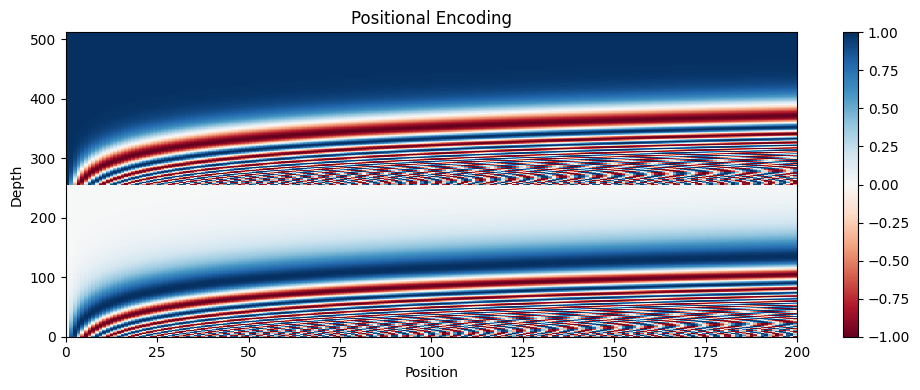

In [ ]:
def positional_encoding(length: int, depth: int) -> tf.Tensor:
    """Sinusoidal positional encodings of shape (length, depth)."""
    half  = depth // 2
    pos   = np.arange(length)[:, np.newaxis]               # (length, 1)
    dims  = np.arange(half)[np.newaxis, :] / half          # (1, half)
    rates = 1.0 / (10_000 ** dims)
    rads  = pos * rates
    enc   = np.concatenate([np.sin(rads), np.cos(rads)], axis=-1)
    return tf.cast(enc, tf.float32)

# Quick visualisation
pos_enc = positional_encoding(200, 512)
plt.figure(figsize=(10, 4))
plt.pcolormesh(pos_enc.numpy().T, cmap="RdBu")
plt.xlabel("Position"); plt.ylabel("Depth"); plt.colorbar()
plt.title("Positional Encoding"); plt.tight_layout(); plt.show()


In [ ]:
class PositionalEmbedding(tf.keras.layers.Layer):
    """Token embedding + sinusoidal positional encoding."""

    def __init__(self, vocab_size: int, d_model: int):
        super().__init__()
        self.d_model   = d_model
        self.embedding = Embedding(vocab_size, d_model, mask_zero=True)
        self.pos_enc   = positional_encoding(2048, d_model)

    def compute_mask(self, *args, **kwargs):
        return self.embedding.compute_mask(*args, **kwargs)

    def call(self, x):
        length = tf.shape(x)[1]
        x = self.embedding(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_enc[tf.newaxis, :length, :]
        return x


# ── Attention sub-layers ───────────────────────────────────────────────────────
class BaseAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__()
        self.mha       = tf.keras.layers.MultiHeadAttention(**kwargs)
        self.layernorm = tf.keras.layers.LayerNormalization()
        self.add       = tf.keras.layers.Add()


class GlobalSelfAttention(BaseAttention):
    def call(self, x):
        x = self.add([x, self.mha(query=x, key=x, value=x)])
        return self.layernorm(x)


class CausalSelfAttention(BaseAttention):
    def call(self, x):
        x = self.add([x, self.mha(query=x, key=x, value=x, use_causal_mask=True)])
        return self.layernorm(x)


class TransformerCrossAttention(BaseAttention):
    def call(self, x, context):
        attn_out, scores = self.mha(
            query=x, key=context, value=context, return_attention_scores=True
        )
        self.last_attn_scores = scores
        x = self.add([x, attn_out])
        return self.layernorm(x)


# ── Feed-forward block ─────────────────────────────────────────────────────────
class FeedForward(tf.keras.layers.Layer):
    def __init__(self, d_model: int, dff: int, dropout_rate: float = 0.1):
        super().__init__()
        self.seq = tf.keras.Sequential([
            Dense(dff, activation="relu"),
            Dense(d_model),
            Dropout(dropout_rate),
        ])
        self.add       = tf.keras.layers.Add()
        self.layernorm = tf.keras.layers.LayerNormalization()

    def call(self, x):
        return self.layernorm(self.add([x, self.seq(x)]))


In [ ]:
# ── Encoder stack ──────────────────────────────────────────────────────────────
class TransformerEncoderLayer(tf.keras.layers.Layer):
    def __init__(self, *, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.self_attn = GlobalSelfAttention(
            num_heads=num_heads, key_dim=d_model, dropout=dropout_rate
        )
        self.ffn = FeedForward(d_model, dff, dropout_rate)

    def call(self, x):
        return self.ffn(self.self_attn(x))


class TransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, *, num_layers, d_model, num_heads, dff,
                 vocab_size, dropout_rate=0.1):
        super().__init__()
        self.pos_embed  = PositionalEmbedding(vocab_size, d_model)
        self.dropout    = Dropout(dropout_rate)
        self.enc_layers = [
            TransformerEncoderLayer(d_model=d_model, num_heads=num_heads,
                                    dff=dff, dropout_rate=dropout_rate)
            for _ in range(num_layers)
        ]

    def call(self, x):
        x = self.dropout(self.pos_embed(x))
        for layer in self.enc_layers:
            x = layer(x)
        return x


# ── Decoder stack ──────────────────────────────────────────────────────────────
class TransformerDecoderLayer(tf.keras.layers.Layer):
    def __init__(self, *, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.causal_attn = CausalSelfAttention(
            num_heads=num_heads, key_dim=d_model, dropout=dropout_rate
        )
        self.cross_attn  = TransformerCrossAttention(
            num_heads=num_heads, key_dim=d_model, dropout=dropout_rate
        )
        self.ffn = FeedForward(d_model, dff, dropout_rate)

    def call(self, x, context):
        x = self.causal_attn(x)
        x = self.cross_attn(x, context)
        self.last_attn_scores = self.cross_attn.last_attn_scores
        return self.ffn(x)


class TransformerDecoder(tf.keras.layers.Layer):
    def __init__(self, *, num_layers, d_model, num_heads, dff,
                 vocab_size, dropout_rate=0.1):
        super().__init__()
        self.pos_embed  = PositionalEmbedding(vocab_size, d_model)
        self.dropout    = Dropout(dropout_rate)
        self.dec_layers = [
            TransformerDecoderLayer(d_model=d_model, num_heads=num_heads,
                                    dff=dff, dropout_rate=dropout_rate)
            for _ in range(num_layers)
        ]
        self.last_attn_scores = None

    def call(self, x, context):
        x = self.dropout(self.pos_embed(x))
        for layer in self.dec_layers:
            x = layer(x, context)
        self.last_attn_scores = self.dec_layers[-1].last_attn_scores
        return x


# ── Full Transformer model ─────────────────────────────────────────────────────
class Transformer(tf.keras.Model):
    def __init__(self, *, num_layers, d_model, num_heads, dff,
                 input_vocab_size, target_vocab_size, dropout_rate=0.1):
        super().__init__()
        self.encoder     = TransformerEncoder(
            num_layers=num_layers, d_model=d_model, num_heads=num_heads,
            dff=dff, vocab_size=input_vocab_size, dropout_rate=dropout_rate,
        )
        self.decoder     = TransformerDecoder(
            num_layers=num_layers, d_model=d_model, num_heads=num_heads,
            dff=dff, vocab_size=target_vocab_size, dropout_rate=dropout_rate,
        )
        self.final_layer = Dense(target_vocab_size)

    def call(self, inputs):
        context, x = inputs
        logits = self.final_layer(self.decoder(x, self.encoder(context)))
        try:
            del logits._keras_mask
        except AttributeError:
            pass
        return logits


In [ ]:
# ── Custom warmup learning-rate schedule ───────────────────────────────────────
class WarmupSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    """Linearly warm up then decay as 1/√step (from 'Attention Is All You Need')."""

    def __init__(self, d_model: int, warmup_steps: int = 4000):
        super().__init__()
        self.d_model      = tf.cast(d_model, tf.float32)
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step  = tf.cast(step, tf.float32)
        arg1  = tf.math.rsqrt(step)
        arg2  = step * (self.warmup_steps ** -1.5)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

    def get_config(self):
        return {"d_model": int(self.d_model.numpy()),
                "warmup_steps": self.warmup_steps}


In [ ]:
# ── Instantiate & compile ──────────────────────────────────────────────────────
TF_NUM_LAYERS = 4
TF_D_MODEL    = 128
TF_DFF        = 512
TF_NUM_HEADS  = 8
TF_DROPOUT    = 0.1

transformer = Transformer(
    num_layers=TF_NUM_LAYERS,
    d_model=TF_D_MODEL,
    num_heads=TF_NUM_HEADS,
    dff=TF_DFF,
    input_vocab_size=int(tokenizers.en.get_vocab_size().numpy()),
    target_vocab_size=int(tokenizers.ar.get_vocab_size().numpy()),
    dropout_rate=TF_DROPOUT,
)

lr_schedule = WarmupSchedule(TF_D_MODEL)
optimizer   = tf.keras.optimizers.Adam(
    lr_schedule, beta_1=0.9, beta_2=0.98, epsilon=1e-9
)

transformer.compile(
    loss=masked_loss,
    optimizer=optimizer,
    metrics=[masked_accuracy],
)

tf_history = transformer.fit(
    train_batches,
    epochs=200,
    validation_data=val_batches,
    callbacks=[EarlyStopping(patience=10)],
)


Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning:

Layer 'global_self_attention' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning:

Layer 'transformer_encoder_layer' (of type TransformerEncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning:

Layer 'causal_self_attention' (of type CausalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.

/usr/

 65/265 ━━━━━━━━━━━━━━━━━━━━ 43:19 13s/step - loss: 8.7483 - masked_accuracy: 0.0043

NameError: name 'tf_history' is not defined

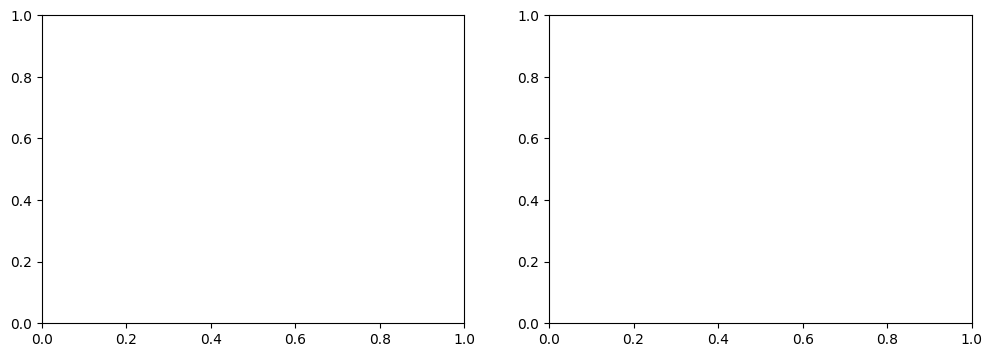

In [ ]:
# ── Learning curves ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, label in zip(
    axes,
    [("loss", "val_loss"), ("masked_accuracy", "val_masked_accuracy")],
    ["Cross-Entropy / token", "Masked Accuracy"],
):
    ax.plot(tf_history.history[metric[0]], label="train")
    ax.plot(tf_history.history[metric[1]], label="val")
    ax.set_xlabel("Epoch"); ax.set_ylabel(label)
    ax.legend(); ax.set_ylim(bottom=0)

plt.suptitle("Transformer Training Curves", fontsize=13)
plt.tight_layout(); plt.show()


In [ ]:
# ── Inference wrapper ──────────────────────────────────────────────────────────
class TranslatorWrapper(tf.Module):
    """Token-by-token autoregressive decoding for any Seq2Seq model."""

    def __init__(self, tokenizers, model):
        self.tokenizers = tokenizers
        self.model      = model

    def __call__(self, sentence: tf.Tensor, max_length: int = MAX_TOKENS):
        if sentence.shape.rank == 0:
            sentence = sentence[tf.newaxis]

        encoder_input = self.tokenizers.en.tokenize(sentence).to_tensor()

        # Decoder start / end tokens from Arabic tokenizer
        start_end = self.tokenizers.ar.tokenize([""])[0]
        start_tok = start_end[0][tf.newaxis]
        end_tok   = start_end[1][tf.newaxis]

        output_array = tf.TensorArray(dtype=tf.int64, size=0, dynamic_size=True)
        output_array = output_array.write(0, start_tok)

        for i in tf.range(max_length):
            output      = tf.transpose(output_array.stack())
            predictions = self.model([encoder_input, output], training=False)
            pred_id     = tf.argmax(predictions[:, -1:, :], axis=-1)
            output_array = output_array.write(i + 1, pred_id[0])
            if pred_id == end_tok:
                break

        output = tf.transpose(output_array.stack())
        text   = self.tokenizers.ar.detokenize(output)[0]
        tokens = self.tokenizers.ar.lookup(output)[0]
        return text, tokens


tf_translator = TranslatorWrapper(tokenizers, transformer)

for en in ["Hello", "How are you?", "I love cats"]:
    ar, _ = tf_translator(tf.constant(en))
    print(f"EN: {en!r}  →  AR: {ar.numpy().decode('utf-8')!r}")


NameError: name 'transformer' is not defined

In [ ]:
# ── Export Transformer ────────────────────────────────────────────────────────
class ExportTranslatorSingle(tf.Module):
    """Accepts a scalar string for SavedModel serving."""

    def __init__(self, wrapper):
        self.wrapper = wrapper

    @tf.function(input_signature=[tf.TensorSpec(shape=[], dtype=tf.string)])
    def __call__(self, sentence):
        result, _ = self.wrapper(sentence, max_length=MAX_TOKENS)
        return result

tf_export = ExportTranslatorSingle(tf_translator)
tf.saved_model.save(tf_export, "./models/transformer_en_ar")
print("Transformer saved.")

reloaded_tf = tf.saved_model.load("./models/transformer_en_ar")
print(reloaded_tf(tf.constant("I love cats")).numpy().decode("utf-8"))


NameError: name 'tf_translator' is not defined

## 6 · Model D — HuggingFace Pretrained (`marefa-nlp/marefa-mt-en-ar`)

A fully pretrained, production-quality machine translation model — useful as a ceiling reference.


In [ ]:
from transformers import pipeline

hf_pipe = pipeline(
    "translation_en_to_ar",
    model="marefa-nlp/marefa-mt-en-ar",
    device=-1,           # use CPU; set to 0 for GPU
)

test_sentences = [
    "Hello my friends! How are you doing today?",
    "Machine Learning is very powerful.",
    "Why did the programmer hate machine learning? "
    "It kept predicting their failed relationships with uncanny accuracy.",
]

for en in test_sentences:
    ar = hf_pipe(en)[0]["translation_text"]
    print(f"EN: {en}")
    print(f"AR: {ar}")
    print()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



config.json: 0.00B [00:00, ?B/s]

KeyError: 'translation'